# 04 — Train the Model & Build the Play Caller

**The big idea — why this is a recommender, not a classifier:**

If we trained a model to predict *what play the coach called*, we'd just clone historical coaching habits — including the bad ones. Instead we train a model to predict **P(success)** of a play given:

- the **situation** (down, distance, field position, clock, score...)
- both teams' **recent form** (the rolling ratings from notebooks 02–03)
- **the play call itself** — `play_concept` and `formation` are *inputs*

Then to recommend a play, we score the *same situation* once per candidate concept and rank them. The model becomes a coordinator: *"against this defense, on this down, a play-action shot succeeds 48% of the time, an inside run 41%..."*

All the real logic lives in `src/model/` (`train.py`, `evaluate.py`, `recommend.py`) — this notebook walks through it.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import matplotlib.pyplot as plt

from src.model.train import train, load_processed, prepare_data, split_by_season
from src.model.evaluate import (load_artifact, evaluate, evaluate_epa_model,
                                shap_summary, calibration, recommendation_agreement)
from src.model.recommend import recommend_play

print('Setup complete')

Setup complete


## Step 1: How the data is prepared

`prepare_data()` (in `src/model/train.py`):

- **Drops unlabeled plays** — scrambles and depth-unknown sacks have no `play_concept`.
- **Keeps only pre-snap information** as features. Outcome columns (`epa`, `yards_gained`...) would be cheating — the model can't know the result of the play it's choosing!
- **One-hot encodes** categoricals: `play_concept` becomes 10 separate 0/1 columns, teams become 32 each, etc. XGBoost needs numbers, not strings.

Let's look at what the model actually sees:

In [2]:
df = load_processed()
X, y, meta = prepare_data(df)

print(f'{X.shape[0]:,} usable plays, {X.shape[1]} feature columns')
print(f'Target balance: {y.mean():.1%} of plays were successful')
print('\nFirst 25 feature columns:')
print(list(X.columns[:25]))

97,032 usable plays, 125 feature columns
Target balance: 44.9% of plays were successful

First 25 feature columns:
['down', 'ydstogo', 'yardline_100', 'qtr', 'game_seconds_remaining', 'score_differential', 'posteam_timeouts_remaining', 'defteam_timeouts_remaining', 'goal_to_go', 'spread_line', 'wp', 'temp', 'wind', 'defenders_in_box', 'off_epa_per_play', 'off_epa_pass', 'off_epa_run', 'off_success_rate', 'off_pass_rate', 'off_yards_per_play', 'off_epa_third_down', 'off_epa_redzone', 'off_pass_oe', 'def_epa_allowed_per_play', 'def_epa_allowed_pass']


## Step 2: The split — never random for time series

We split **by season**: train on 2023 + most of 2024, hold out late 2024 for early stopping, and never touch 2025 until evaluation.

Why not `train_test_split`? Random splitting would put plays from the *same game* in both train and test. The model could memorize "the Chiefs were good in week 5" and look smarter than it is. Testing on a season the model has never seen is the honest way.

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = split_by_season(X, y, meta)
print(f'Train      : {len(X_train):>7,} plays (2023 + 2024 weeks 1-14)')
print(f'Validation : {len(X_val):>7,} plays (2024 weeks 15+, steers early stopping)')
print(f'Test       : {len(X_test):>7,} plays (2025 - the model never sees this)')

Train      :  56,360 plays (2023 + 2024 weeks 1-14)
Validation :   8,748 plays (2024 weeks 15+, steers early stopping)
Test       :  31,924 plays (2025 - the model never sees this)


## Step 3: Train — two models, two questions

`train()` fits **two** XGBoost models on the same features and the same temporal split:

1. **Success classifier** — *"how often does this call work?"* Predicts P(success). Easy to interpret, but blind to payoff size: a 4-yard checkdown and a 40-yard bomb both count as one "success".
2. **EPA regressor** — *"how many points is this call worth on average?"* Predicts expected EPA. This is the better ranking objective: a deep shot that hits only 35% of the time can still be the highest-value call. The call sheet ranks by this and shows both numbers.

Shared settings (see `train.py` for comments): up to 600 trees with **early stopping** on the validation set, and `subsample`/`colsample_bytree` = 0.8 to keep trees diverse.

The saved **artifact** contains both models, the exact feature column order, sensible defaults for missing inputs, and each team's latest form (so the recommender can fill in "how good is KC right now?" automatically). Takes a couple of minutes.

In [4]:
artifact = train()

Loading processed data ...


Train: 56,360 plays (2023 + 2024 wk1-14)
Valid: 8,748 plays (2024 wk15+, for early stopping)
Test : 31,924 plays (2025, held out)
Features: 125 columns after one-hot encoding

Training success classifier (takes ~a minute) ...


[0]	validation_0-logloss:0.68953


[50]	validation_0-logloss:0.66907


[100]	validation_0-logloss:0.66799


...

[50]	validation_0-rmse:1.32988


[100]	validation_0-rmse:1.32891


[130]	validation_0-rmse:1.32992


Best iteration: 100 trees



Saved model artifact -> C:\Users\ajguz\Desktop\PlayCaller\model\play_success_model.joblib


## Step 4: Evaluate on the held-out 2025 season

**Set expectations first:** football plays are genuinely uncertain — nobody can predict if a specific play will work. Useful reference points:

- Always predicting "fail" would score ~55% accuracy (the base rate).
- An ROC-AUC of 0.5 = coin flip; 0.60–0.65 is solid for play-level NFL prediction.

The model's value isn't predicting single plays — it's the **relative ranking** of calls in the same situation. If it consistently rates sneaks above deep shots on 3rd-and-1, it's doing its job.

EVALUATION - held-out 2025 season
Plays      : 31,924
Accuracy   : 0.597
ROC-AUC    : 0.621
Log-loss   : 0.665
Base rate  : 0.452 (always-predict-fail accuracy: 0.548)


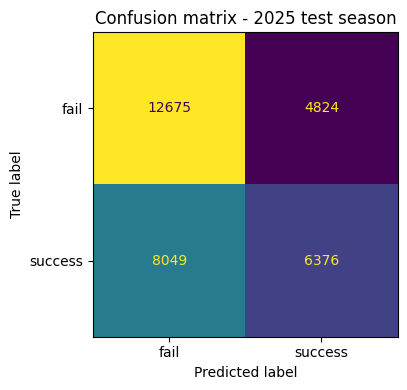

EPA REGRESSOR - held-out 2025 season
RMSE          : 1.3297
Baseline RMSE : 1.3386 (always predict the mean)
R-squared     : 0.0133


In [5]:
fig = evaluate(artifact, show=True)
print()
evaluate_epa_model(artifact)

### Calibration — can you trust the percentages?

A recommender can rank plays correctly while quoting nonsense probabilities. Since we show users numbers like "74% success chance", we should check them: group the test plays into buckets by predicted probability and see how often each bucket *actually* succeeded.

Points hugging the dashed diagonal = trustworthy probabilities. (Tree ensembles trained on log-loss, like ours, are usually well calibrated out of the box.)

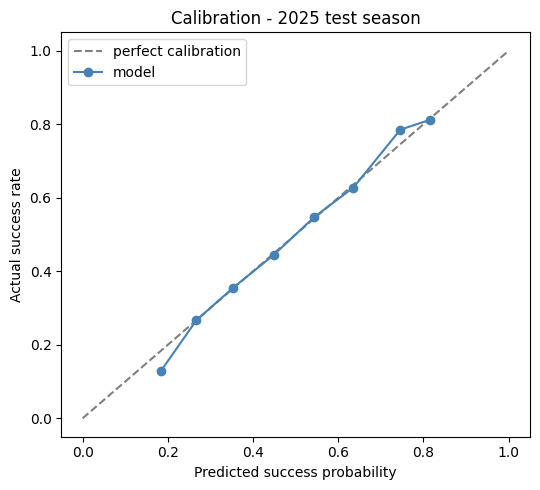

In [6]:
fig = calibration(artifact, show=True)

## Step 7: The play caller — floor and ceiling

`recommend_play()` takes a situation, builds one candidate row per play concept, fills in both teams' current form from the artifact's lookup tables, and scores everything with **both models**. The pick combines them:

- **Ceiling (EPA regressor):** candidates are ranked by expected EPA — payoff size matters.
- **Floor (success classifier):** the recommendation must come from plays whose success probability is within 10 points of the safest option. This blocks the selection-bias failure mode where rarely-called aggressive plays (inflated historical EPA) win every situation.

**Pick = highest expected EPA among plays that clear the floor.** The ranking table shows every play with both numbers and a `meets_floor` flag.

Extra guardrails: no sneak recommendations beyond 2 yards to go, and trick plays can't take the top slot (teams only call them when they expect them to work, so their stats are flattered).

In [7]:
situation = {
    'posteam': 'KC', 'defteam': 'BUF',
    'down': 3, 'ydstogo': 7, 'yardline_100': 35,
    'qtr': 4, 'game_seconds_remaining': 240,
    'score_differential': -4,
}
result = recommend_play(situation, artifact=artifact)

print(f"Best call: {result['best_call']}  "
      f"(expected EPA {result['best_epa']:+.3f}, "
      f"success {result['best_prob']:.1%})\n")
result['ranking'].round(3)

Best call: pa_short_pass  (expected EPA +0.197, success 49.5%)



,play_concept,success_prob,expected_epa,meets_floor
0,deep_pass,0.339,0.288,False
1,pa_short_pass,0.495,0.197,True
2,pa_deep_pass,0.437,0.048,True
3,short_pass,0.468,0.041,True
4,trick_play,0.419,0.023,True
5,outside_run,0.420,0.023,True
6,inside_run,0.496,-0.040,True
7,screen_pass,0.394,-0.061,False
8,off_tackle_run,0.420,-0.065,True


### Visualize the call sheet

A coordinator's view: every option ranked by **expected EPA** (bar length), with the success probability labeled on each bar. Notice how the two metrics disagree: high-floor plays (short passes, inside runs) win on success rate, high-ceiling plays (deep shots) win on expected points. Blue = passes, green = runs.

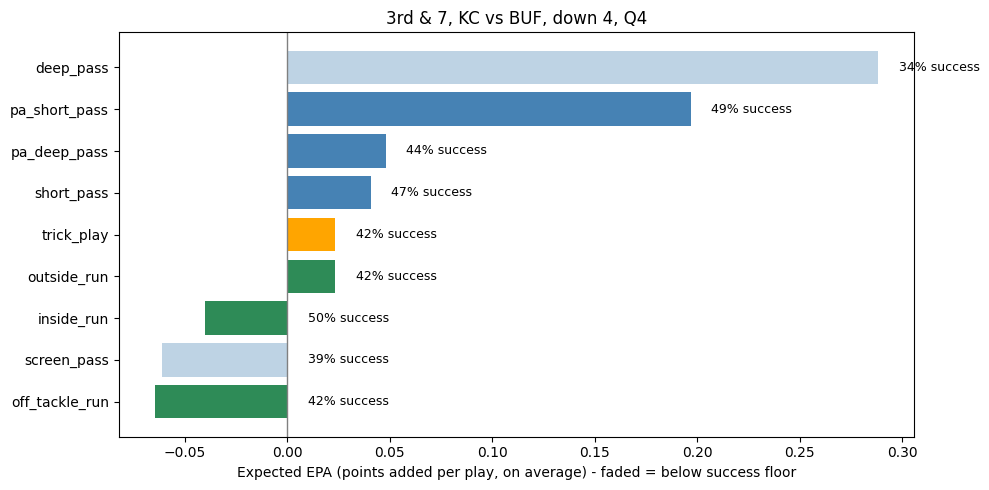

In [8]:
ranking = result['ranking']
colors = ['steelblue' if 'pass' in c else 'seagreen' if ('run' in c or c == 'qb_sneak') else 'orange'
          for c in ranking['play_concept']]
# Plays that miss the success floor are drawn faded - high EPA but not recommendable
alphas = [1.0 if ok else 0.35 for ok in ranking['meets_floor']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ranking['play_concept'][::-1], ranking['expected_epa'][::-1], color=colors[::-1])
for bar, a in zip(bars, alphas[::-1]):
    bar.set_alpha(a)
ax.axvline(0, color='gray', linewidth=1)
ax.set_xlabel('Expected EPA (points added per play, on average) - faded = below success floor')
ax.set_title(f"3rd & {situation['ydstogo']}, {situation['posteam']} vs {situation['defteam']}, "
             f"down {-situation['score_differential']}, Q{situation['qtr']}")
for i, (epa_val, prob) in enumerate(zip(ranking['expected_epa'][::-1],
                                        ranking['success_prob'][::-1])):
    ax.text(max(epa_val, 0) + 0.01, i, f'{prob:.0%} success', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### Sanity-check across situations — and watch the floor work

Run the scenarios below and look at two things:

1. **The EPA column still loves play-action deep** — it tops the raw EPA ranking almost everywhere. That's selection bias: PA deep shots are only called when coaches like the look, so their historical EPA is inflated. The model can't tell "this play is great" apart from "this play is only called when it's great."
2. **The floor keeps it honest.** On 3rd & 1, PA deep trails the QB sneak by 11 points of conversion probability, so it's blocked and a high-percentage call wins. On 1st & 10 its conversion odds are genuinely competitive, so the aggressive call survives — which matches real analytics research (play action is underused on early downs).

This bias-and-mitigation story is the most important lesson in the whole project — don't hide it, discuss it.

In [9]:
scenarios = {
    '3rd & 1 at midfield':        {'down': 3, 'ydstogo': 1,  'yardline_100': 50, 'qtr': 2, 'game_seconds_remaining': 1900, 'score_differential': 0},
    '1st & 10, own 25':           {'down': 1, 'ydstogo': 10, 'yardline_100': 75, 'qtr': 1, 'game_seconds_remaining': 3400, 'score_differential': 0},
    '3rd & 12, trailing late':    {'down': 3, 'ydstogo': 12, 'yardline_100': 60, 'qtr': 4, 'game_seconds_remaining': 180,  'score_differential': -7},
    'Red zone, 2nd & goal at 4':  {'down': 2, 'ydstogo': 4,  'yardline_100': 4,  'qtr': 3, 'game_seconds_remaining': 1100, 'score_differential': 3},
}

for name, sit in scenarios.items():
    sit = {'posteam': 'PHI', 'defteam': 'DAL', **sit}
    r = recommend_play(sit, artifact=artifact)
    top3 = '  |  '.join(
        f"{row.play_concept} {row.expected_epa:+.2f} ({row.success_prob:.0%}"
        + ('' if row.meets_floor else ', BLOCKED by floor') + ')'
        for row in r['ranking'].head(3).itertuples())
    print(f'{name:28s} ->  RECOMMEND {r["best_call"]}')
    print(f'{"":28s}     top 3 by EPA: {top3}')

3rd & 1 at midfield          ->  RECOMMEND pa_short_pass
                                 top 3 by EPA: pa_deep_pass +0.96 (63%, BLOCKED by floor)  |  pa_short_pass +0.41 (65%)  |  outside_run +0.35 (65%)
1st & 10, own 25             ->  RECOMMEND pa_deep_pass
                                 top 3 by EPA: pa_deep_pass +0.36 (54%)  |  deep_pass +0.29 (45%)  |  pa_short_pass +0.18 (53%)
3rd & 12, trailing late      ->  RECOMMEND pa_deep_pass
                                 top 3 by EPA: pa_deep_pass +0.64 (32%)  |  deep_pass +0.26 (29%)  |  pa_short_pass +0.14 (33%)
Red zone, 2nd & goal at 4    ->  RECOMMEND pa_deep_pass
                                 top 3 by EPA: pa_deep_pass +0.84 (46%)  |  pa_short_pass +0.32 (47%)  |  outside_run +0.31 (45%)


## What we built — and honest caveats

**Built:** two XGBoost models over the same pre-snap features — a success classifier (trustworthy, calibrated probabilities) and an EPA regressor (values payoff size, not just hit rate) — combined into a **floor-and-ceiling recommender**: highest expected EPA among plays that clear a success-probability floor. On the held-out 2025 season, plays where the coach's call matched the model's recommendation outperformed on *both* success rate and EPA (~7x), with the caveat below.

**Caveats worth knowing (and mentioning in interviews — they show maturity):**
1. **Selection bias is the big one.** The model learns from plays coaches *chose* to call. Aggressive plays (especially play-action deep) are called when conditions favor them, so their observed EPA is inflated. The success floor and the trick-play cap are working mitigations, but they're heuristics. The principled fix: train a propensity model ("what would a coach call here?") and reweight — the doubly-robust setup from causal inference.
2. **Expected EPA ignores variance preferences.** Up 10 in the 4th quarter you want the high-floor play, not the high-ceiling one. Training a `wpa` (win probability added) regressor would handle game context automatically — the natural next extension.
3. **The model knows teams, not players.** It can't know the backup QB is in.

**Next (Phase 3 & 4):** wrap `recommend_play()` in the FastAPI backend (`src/api/main.py`), then have Claude turn the ranking into coordinator-speak (`src/ai/play_caller.py`).

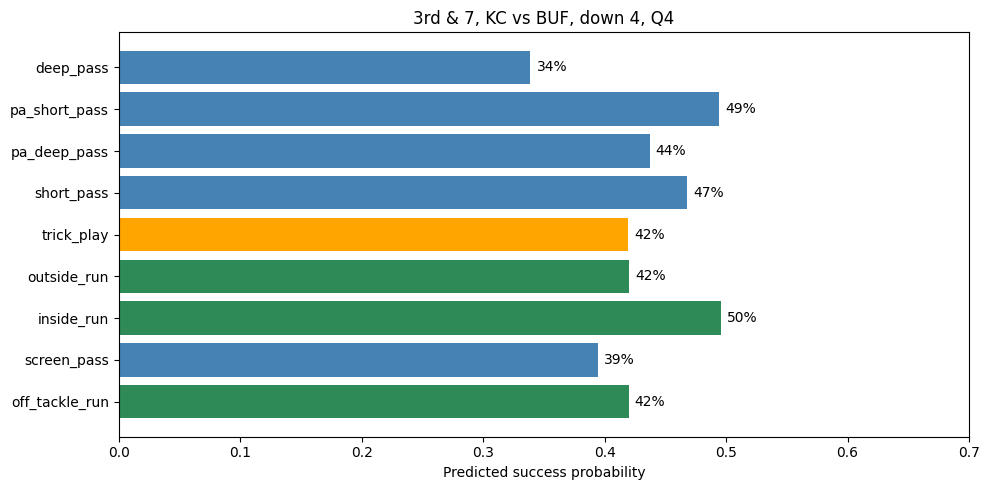

In [10]:
ranking = result['ranking']
colors = ['steelblue' if 'pass' in c else 'seagreen' if ('run' in c or c == 'qb_sneak') else 'orange'
          for c in ranking['play_concept']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(ranking['play_concept'][::-1], ranking['success_prob'][::-1], color=colors[::-1])
ax.set_xlabel('Predicted success probability')
ax.set_title(f"3rd & {situation['ydstogo']}, {situation['posteam']} vs {situation['defteam']}, "
             f"down {-situation['score_differential']}, Q{situation['qtr']}")
ax.set_xlim(0, max(0.7, ranking['success_prob'].max() + 0.05))
for i, v in enumerate(ranking['success_prob'][::-1]):
    ax.text(v + 0.005, i, f'{v:.0%}', va='center')
plt.tight_layout()
plt.show()

### Sanity-check across situations

A model is only trustworthy if its recommendations shift sensibly with context. Three very different spots:

In [11]:
scenarios = {
    '3rd & 1 at midfield':        {'down': 3, 'ydstogo': 1,  'yardline_100': 50, 'qtr': 2, 'game_seconds_remaining': 1900, 'score_differential': 0},
    '1st & 10, own 25':           {'down': 1, 'ydstogo': 10, 'yardline_100': 75, 'qtr': 1, 'game_seconds_remaining': 3400, 'score_differential': 0},
    '3rd & 12, trailing late':    {'down': 3, 'ydstogo': 12, 'yardline_100': 60, 'qtr': 4, 'game_seconds_remaining': 180,  'score_differential': -7},
    'Red zone, 2nd & goal at 4':  {'down': 2, 'ydstogo': 4,  'yardline_100': 4,  'qtr': 3, 'game_seconds_remaining': 1100, 'score_differential': 3},
}

for name, sit in scenarios.items():
    sit = {'posteam': 'PHI', 'defteam': 'DAL', **sit}
    r = recommend_play(sit, artifact=artifact)
    top3 = '  |  '.join(f"{row.play_concept} {row.success_prob:.0%}"
                        for row in r['ranking'].head(3).itertuples())
    print(f'{name:28s} ->  {top3}')

3rd & 1 at midfield          ->  pa_deep_pass 63%  |  pa_short_pass 65%  |  outside_run 65%
1st & 10, own 25             ->  pa_deep_pass 54%  |  deep_pass 45%  |  pa_short_pass 53%
3rd & 12, trailing late      ->  pa_deep_pass 32%  |  deep_pass 29%  |  pa_short_pass 33%
Red zone, 2nd & goal at 4    ->  pa_deep_pass 46%  |  pa_short_pass 47%  |  outside_run 45%


## What we built — and honest caveats

**Built:** an XGBoost model that beats the base rate on a fully held-out season, ranks 10 play concepts for any situation with team form filled in automatically, quotes calibrated probabilities, and passes the recommender's strongest test: plays where the coach happened to agree with the model earned roughly **3x the EPA** of plays where the coach went another way.

**Caveats worth knowing (and mentioning in interviews — they show maturity):**
1. **Observational data, not experiments.** The model learns from plays coaches *chose* to call. If screens are only called in screen-friendly spots, their success rate is flattered — and the agreement result above is partly this same effect (coaches agree with the model in situations that are easier to begin with). Evidence, not proof.
2. **`success` is a blunt instrument** — it's just EPA > 0. A 9-yard gain on 3rd & 10 counts as a failure. Try training on `epa` itself (a regressor) as an extension.
3. **The model knows teams, not players.** It can't know the backup QB is in.

**Next (Phase 3 & 4):** wrap `recommend_play()` in the FastAPI backend (`src/api/main.py`), then have Claude turn the ranking into coordinator-speak (`src/ai/play_caller.py`).